## Training Notebook

### Purpose
This notebook trains and compares 4 machine learning models for anomaly detection using the collected data.

### Models tested
- Logistic Regression
- Gradient Boosting
- Isolation Forest
- One-Class SVM

In [2]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import fbeta_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer
import helper
from dataclasses import dataclass
from typing import Any
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

## Load Dataset


In [3]:
data = pd.read_csv("../dataset.csv")

print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 44284 entries, 0 to 44283
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   cpu_usage              44284 non-null  float64
 1   memory_usage           44284 non-null  float64
 2   tcp_connections_total  44284 non-null  int64  
 3   udp_sockets_total      44284 non-null  int64  
 4   tcp_established        44284 non-null  int64  
 5   tcp_listen             44284 non-null  int64  
 6   tcp_time_wait          44284 non-null  int64  
 7   tcp_close_wait         44284 non-null  int64  
 8   unique_remote_ips      44284 non-null  int64  
 9   unique_local_ports     44284 non-null  int64  
 10  unique_remote_ports    44284 non-null  int64  
 11  bytes_recv             44284 non-null  int64  
 12  bytes_sent             44284 non-null  int64  
 13  packets_recv           44284 non-null  int64  
 14  packets_sent           44284 non-null  int64  
 15  timestamp    

In [4]:
resampled_data = helper.aggregate_dataframe_into_seconds_interval(data, 20)

resampled_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2336 entries, 2026-03-11 18:31:00 to 2026-04-04 17:37:00
Data columns (total 57 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cpu_usage_mean              2336 non-null   float64
 1   cpu_usage_max               2336 non-null   float64
 2   cpu_usage_min               2336 non-null   float64
 3   cpu_usage_std               2336 non-null   float64
 4   memory_usage_mean           2336 non-null   float64
 5   memory_usage_max            2336 non-null   float64
 6   memory_usage_min            2336 non-null   float64
 7   memory_usage_std            2336 non-null   float64
 8   tcp_connections_total_mean  2336 non-null   float64
 9   tcp_connections_total_max   2336 non-null   float64
 10  tcp_connections_total_min   2336 non-null   float64
 11  tcp_connections_total_std   2336 non-null   float64
 12  udp_sockets_total_mean      2336 non-null   float64
 13  udp_sock

In [5]:
resampled_data = resampled_data.sort_index()

# Forward time split: train on first 80%, test on last 20%
split_idx = int(len(resampled_data) * 0.8)
train_data = resampled_data.iloc[:split_idx]
test_data = resampled_data.iloc[split_idx:]

# Separate features and labels
X_train = train_data.drop(["label"], axis=1)
y_train = train_data["label"]

X_test = test_data.drop(["label"], axis=1)
y_test = test_data["label"]

In [6]:
label_counts = data["label"].value_counts()
label_percentages = data["label"].value_counts(normalize=True) * 100

normal_count = label_counts[0]
anomaly_count = label_counts[1]

normal_percentage = label_percentages[0]
anomaly_percentage = label_percentages[1]

print(f"Normal rows: {normal_count} ({normal_percentage:.2f}%)")
print(f"Anomaly rows: {anomaly_count} ({anomaly_percentage:.2f}%)")

Normal rows: 29452 (66.51%)
Anomaly rows: 14832 (33.49%)


### Evaluate Model Supervised Classifiers (lab-notebook code)


In [7]:
@dataclass
class Evaluation:
    accuracy: float
    precision: float
    recall: float
    f1_score: float
    f2_score: float
    model_config: Any

In [8]:
def evaluate_model(y_true, y_pred, model_name, model_config) -> Evaluation:

    print(f"\n--- Evaluation for: {model_name} ---")

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Normal", "Attacked"],
        yticklabels=["Normal", "Attacked"],
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    TN, FP, FN, TP = cm.ravel()

    print(f"True Positives (TP): {TP}")
    print(f"True Negatives (TN): {TN}")
    print(f"False Positives (FP): {FP}")
    print(f"False Negatives (FN): {FN}")

    # Epsilon was changed to a very small value to not allow division by zero
    epsilon = 1e-6

    accuracy = (TP + TN) / (TP + TN + FP + FN + epsilon)
    print(f"\nAccuracy: {accuracy:.4f}")

    precision = TP / (TP + FP + epsilon)
    print(f"Precision: {precision:.4f}")

    recall = TP / (TP + FN + epsilon)
    print(f"Recall: {recall:.4f}")

    f1_score = 2 * (precision * recall) / (precision + recall + epsilon)
    print(f"F1-Score: {f1_score:.4f}")

    f2_score = fbeta_score(y_true, y_pred, beta=2, zero_division=0)
    print(f"F2-Score: {f2_score:.4f}")

    return Evaluation(
        accuracy=accuracy,
        precision=precision,
        recall=recall,
        f1_score=f1_score,
        f2_score=f2_score,
        model_config=model_config,
    )

### Supervised Models


Starting logistic regression hyperparameter tuning...

--- Evaluation for: Logistic Regression ---


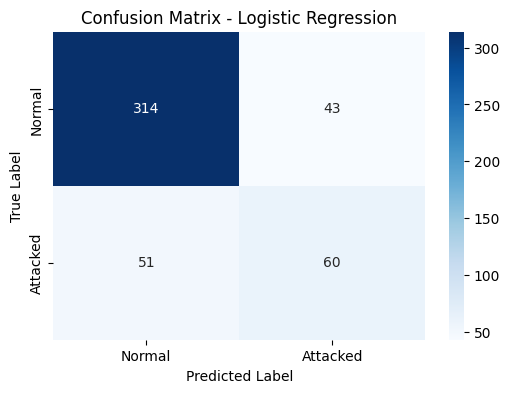

True Positives (TP): 60
True Negatives (TN): 314
False Positives (FP): 43
False Negatives (FN): 51

Accuracy: 0.7991
Precision: 0.5825
Recall: 0.5405
F1-Score: 0.5607
F2-Score: 0.5484


In [9]:
# The Pipeline is use to prevent leaks: it runs the StandardScaler
# on each fold's training data only, and to the validation fold.
pipeline = Pipeline(
    [("standard_scaler", StandardScaler()), ("lr", LogisticRegression(random_state=42))]
)

# The fbeta_score with beta=2 gives more weight to recall, which is important in anomaly detection to minimize false negatives.
scorer = make_scorer(fbeta_score, beta=2, zero_division=0)


## Param grid

# C controls how strong the regularization is.
# Smaller values = stronger regularization (simpler model, less overfitting).
# Larger values = weaker regularization (model can fit the data more closely).

# The solver is the optimization algorithm used to find the best model parameters.

# class_weight helps when the dataset is imbalanced.
# "balanced" automatically gives more importance to the minority class.

# max_iter sets how long the solver is allowed to run.
# If the model does not converge, increasing this value can help.

# l1_ratio is only relevant when using the 'saga' solver with elastic-net penalty.
# 0 → pure L2 regularization
# 1 → pure L1 regularization
# values in between → mix of L1 and L2

logistic_regression_param_grid = [
    {
        "lr__C": np.logspace(-4, 4, 20),
        "lr__solver": ["lbfgs"],
        "lr__l1_ratio": [0],
        "lr__class_weight": ["balanced", None],
        "lr__max_iter": [300, 500, 1000],
    }
]

# Provides train/test to split time-ordered data, where other cross-validation methods are inappropriate, as they would lead to training on future data and evaluating on past data. Instead of randomly shuffling the data, as in traditional k-fold, TimeSeriesSplit maintains the temporal order.
cv = TimeSeriesSplit(n_splits=5)

# GridSearch - will allow us to find the best model from all the possible configuration above
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=logistic_regression_param_grid,
    cv=cv,
    scoring=scorer,
    n_jobs=-1,
    verbose=0,
)

# Train the model
print("Starting logistic regression hyperparameter tuning...")
grid_search.fit(X_train, y_train)

# Get the best model and make predictions
best_lr_model = grid_search.best_estimator_
y_pred_lr = best_lr_model.predict(X_test)

logistic_regression_evaluation = evaluate_model(
    y_test, y_pred_lr, "Logistic Regression", model_config=best_lr_model
)

Starting gb hyperparameter tuning...

--- Evaluation for: GradientBoosting ---


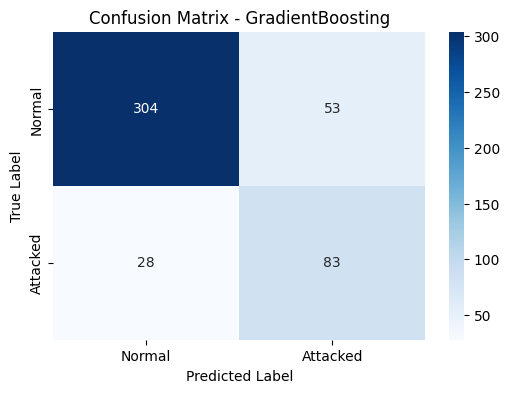

True Positives (TP): 83
True Negatives (TN): 304
False Positives (FP): 53
False Negatives (FN): 28

Accuracy: 0.8269
Precision: 0.6103
Recall: 0.7477
F1-Score: 0.6721
F2-Score: 0.7155


In [10]:
gb = GradientBoostingClassifier(random_state=42)

scorer = make_scorer(fbeta_score, beta=2)

# Define parameter grid for Gradient Boosting Classifier

# n_estimators: Defines the number of trees to be added. More estimators usually lead to better performance, but also increase the risk of overfitting.

# learning_rate: Controls the contribution of each tree to the final prediction. A smaller value makes the model more robust but requires more estimators to achieve high performance.

# max_depth: Specifies the maximum depth of each individual tree. Shallow trees might underfit while deeper trees can overfit. It's essential to find the right depth.

# min_samples_split: Defines the minimum number of samples required to split an internal node. Increasing this value helps control overfitting by preventing the model from learning overly specific patterns.

# subsamplefloat, default=1.0: subsample tells the model how much of the data to use for each tree.

param_grid_gb = {
    "n_estimators": [200, 400, 600],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_samples_leaf": [10, 20],
    "subsample": [0.8, 1.0],
    "criterion": ["friedman_mse"],
}

cv = TimeSeriesSplit(n_splits=5)

grid_gb = GridSearchCV(
    estimator=gb, param_grid=param_grid_gb, cv=cv, scoring=scorer, n_jobs=-1, verbose=0
)

print("Starting gb hyperparameter tuning...")
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_

y_pred_gb = best_gb.predict(X_test)
gb_evaluation = evaluate_model(
    y_test, y_pred_gb, "GradientBoosting", model_config=best_gb
)

### Unsupervised Models


Best parameters:
{'n_estimators': 100, 'contamination': 0.3, 'max_features': 1.0}
Best F2 score:
0.565843621399177

--- Evaluation for: Isolation Forest ---


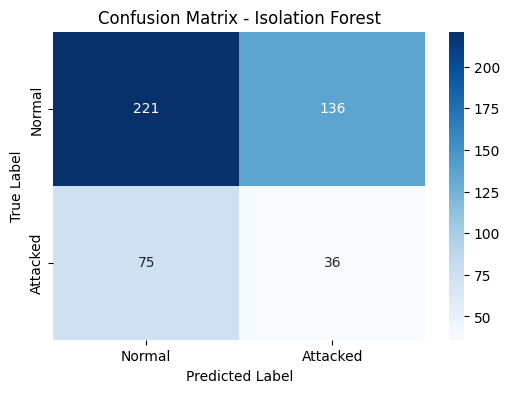

True Positives (TP): 36
True Negatives (TN): 221
False Positives (FP): 136
False Negatives (FN): 75

Accuracy: 0.5491
Precision: 0.2093
Recall: 0.3243
F1-Score: 0.2544
F2-Score: 0.2922


In [11]:
# n_estimators = number of trees.
# More trees can make the model more stable, but training becomes slower.
n_estimators_list = [100, 200, 300, 400]

# contamination = expected proportion of anomalies.
# Higher values make the model mark more points as anomalies.
# If this is too high, the model may give too many false alarms.
# If this is too low, the model may miss real anomalies.
contamination_list = [0.05, 0.1, 0.2, 0.3]

# max_features = how many features each tree can use.
# Lower values add randomness.
# This can help reduce overfitting, but if too low the model may underfit.
max_features_list = [0.6, 0.8, 1.0]

# Keep only normal rows for training.
X_train_normal = X_train[y_train == 0]

# Split training normal data: 80% to train, 20% to validate
val_split = int(len(X_train_normal) * 0.8)
X_train_normal_fit = X_train_normal.iloc[:val_split]
X_train_normal_val = X_train_normal.iloc[val_split:]

# The validation set will be used to evaluate the model during hyperparameter tuning.
val_start_idx = X_train_normal.index[val_split]
X_val = X_train[X_train.index >= val_start_idx]
y_val = y_train[y_train.index >= val_start_idx]

# Scale the data.
scaler = StandardScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal_fit)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


best_score = -1
best_params = None

for n_estimators in n_estimators_list:
    for contamination in contamination_list:
        for max_features in max_features_list:
            model = IsolationForest(
                n_estimators=n_estimators,
                contamination=contamination,
                max_features=max_features,
                random_state=42,
            )

            model.fit(X_train_normal_scaled)
            predictions = model.predict(X_val_scaled)

            y_pred = []
            for value in predictions:
                if value == -1:
                    y_pred.append(1)
                else:
                    y_pred.append(0)

            score = fbeta_score(y_val, y_pred, beta=2, zero_division=0)

            if score > best_score:
                best_score = score
                best_params = {
                    "n_estimators": n_estimators,
                    "contamination": contamination,
                    "max_features": max_features,
                }

print("Best parameters:")
print(best_params)

print("Best F2 score:")
print(best_score)

# Train the final model with the best parameters.
iso_model = IsolationForest(
    n_estimators=best_params["n_estimators"],
    contamination=best_params["contamination"],
    max_features=best_params["max_features"],
    random_state=42,
)

scaler = StandardScaler()
X_train_normal_scaled_full = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

iso_model.fit(X_train_normal_scaled_full)
final_predictions = iso_model.predict(X_test_scaled)

final_y_pred = []
for value in final_predictions:
    if value == -1:
        final_y_pred.append(1)
    else:
        final_y_pred.append(0)

isolation_forest_evaluation = evaluate_model(
    y_test, final_y_pred, "Isolation Forest", model_config=iso_model
)

Best parameters:
{'nu': 0.01, 'gamma': 0.1}
Best F2 score:
0.5524861878453039

--- Evaluation for: One-Class SVM ---


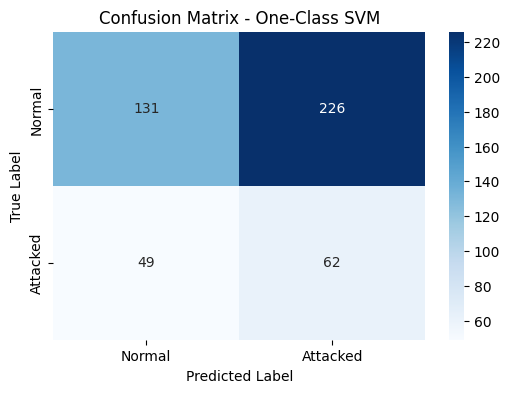

True Positives (TP): 62
True Negatives (TN): 131
False Positives (FP): 226
False Negatives (FN): 49

Accuracy: 0.4124
Precision: 0.2153
Recall: 0.5586
F1-Score: 0.3108
F2-Score: 0.4235


In [12]:
# nu = roughly how many points the model is allowed to treat as anomalies.
# Higher values make the model more strict.
# If this is too high, the model may flag too many normal points.
# If this is too low, the model may miss real anomalies.
nu_list = [0.01, 0.05, 0.1, 0.2, 0.3]

# gamma = how flexible the boundary is.
# Lower values give a smoother and simpler boundary.
# Higher values give a tighter and more detailed boundary.
# If gamma is too high, the model can overfit.
# If gamma is too low, the model can underfit.
gamma_list = ["scale", "auto", 0.001, 0.01, 0.1]

# Keep only normal rows for training.
# One-Class SVM learns normal behavior first,
# then it treats unusual points as anomalies.
X_train_normal = X_train[y_train == 0]

# Split training normal data: 80% to train, 20% to validate
val_split = int(len(X_train_normal) * 0.8)
X_train_normal_fit = X_train_normal.iloc[:val_split]

# The validation set will be used to evaluate the model during hyperparameter tuning.
val_start_idx = X_train_normal.index[val_split]
X_val = X_train[X_train.index >= val_start_idx]
y_val = y_train[y_train.index >= val_start_idx]

# Scale the data.
scaler = StandardScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal_fit)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Keep track of the best result.
best_score = -1
best_params = None


for nu in nu_list:
    for gamma in gamma_list:
        model = OneClassSVM(nu=nu, gamma=gamma)

        # Train the model on normal training data only.
        model.fit(X_train_normal_scaled)
        predictions = model.predict(X_val_scaled)

        # Change the predictions into:
        # 0 = normal
        # 1 = anomaly
        y_pred = []
        for value in predictions:
            if value == -1:
                y_pred.append(1)
            else:
                y_pred.append(0)

        score = fbeta_score(y_val, y_pred, beta=2, zero_division=0)

        if score > best_score:
            best_score = score
            best_params = {"nu": nu, "gamma": gamma}


print("Best parameters:")
print(best_params)
print("Best F2 score:")
print(best_score)

oneclass_svm_model = OneClassSVM(nu=best_params["nu"], gamma=best_params["gamma"])

# Train the final model.
scaler = StandardScaler()
X_train_normal_scaled_full = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)

oneclass_svm_model.fit(X_train_normal_scaled_full)
final_predictions = oneclass_svm_model.predict(X_test_scaled)

# Change predictions into:
# 0 = normal
# 1 = anomaly
final_y_pred = []
for value in final_predictions:
    if value == -1:
        final_y_pred.append(1)
    else:
        final_y_pred.append(0)

# Evaluate the final model.
svm_evaluation = evaluate_model(
    y_test, final_y_pred, "One-Class SVM", model_config=oneclass_svm_model
)

### Compare model results


In [13]:
evaluations = [
    ("LogisticRegression", logistic_regression_evaluation),
    ("GradientBoosting", gb_evaluation),
    ("IsolationForest", isolation_forest_evaluation),
    ("OneClassSVM", svm_evaluation),
]

best_name = None
best_model_config = None
best_f2_score = -1

for name, eval in evaluations:
    if eval.f2_score > best_f2_score:
        best_f2_score = eval.f2_score
        best_name = name
        best_model_config = eval.model_config

print(f"Best model: {best_name}")
print(f"F2 Score: {best_f2_score:.4f}")

Best model: GradientBoosting
F2 Score: 0.7155


                    accuracy  precision  recall  f1_score  f2_score
Model                                                              
LogisticRegression    0.7991     0.5825  0.5405    0.5607    0.5484
GradientBoosting      0.8269     0.6103  0.7477    0.6721    0.7155
IsolationForest       0.5491     0.2093  0.3243    0.2544    0.2922
OneClassSVM           0.4124     0.2153  0.5586    0.3108    0.4235


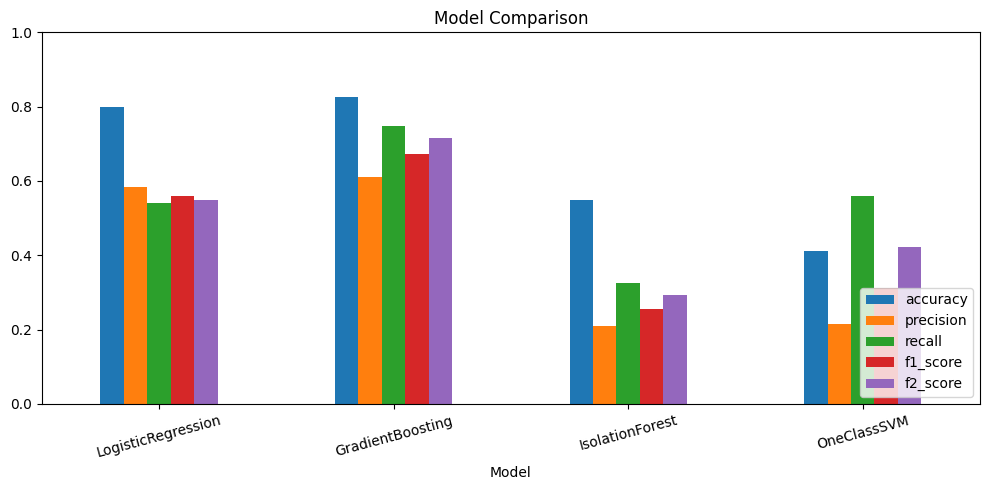

In [14]:
metrics = ["accuracy", "precision", "recall", "f1_score", "f2_score"]
rows = []
for name, ev in evaluations:
    rows.append([name, ev.accuracy, ev.precision, ev.recall, ev.f1_score, ev.f2_score])

df_results = pd.DataFrame(rows, columns=["Model"] + metrics)
df_results = df_results.set_index("Model").round(4)
print(df_results.to_string())


df_results.plot(kind="bar", figsize=(10, 5), ylim=(0, 1))
plt.title("Model Comparison")
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Save the most performant Model


In [15]:
import joblib
from datetime import datetime

best_scaler = None
if best_name == "IsolationForest" or best_name == "OneClassSVM":
    best_scaler = scaler

model_name = {"model": best_model_config, "scaler": best_scaler}

now = datetime.now().strftime("%Y_%m_%d_%H%M%S")
model_file_name = best_name + "_" + now + ".pkl"

joblib.dump(model_name, model_file_name)

['GradientBoosting_2026_04_04_202009.pkl']

In [16]:
# The table below shows the Precision, Recall, F1, and F2 scores
# for all four models evaluated on the test set.

rows = []
for model_name, ev in evaluations:
    rows.append(
        {
            "Model": model_name,
            "Precision": ev.precision,
            "Recall": ev.recall,
            "F1": ev.f1_score,
            "F2": ev.f2_score,
        }
    )

results_table = pd.DataFrame(rows).set_index("Model").round(4)

print(
    "The table below shows the Precision, Recall, F1, and F2 scores for all four models evaluated on the test set."
)
display(results_table)

The table below shows the Precision, Recall, F1, and F2 scores for all four models evaluated on the test set.


,Precision,Recall,F1,F2
Model,,,,
LogisticRegression,0.5825,0.5405,0.5607,0.5484
GradientBoosting,0.6103,0.7477,0.6721,0.7155
IsolationForest,0.2093,0.3243,0.2544,0.2922
OneClassSVM,0.2153,0.5586,0.3108,0.4235


## References

- [Scikit-learn – Preprocessing Data](https://scikit-learn.org/stable/modules/preprocessing.html)

- [Scikit-learn – Pipeline and Composite Estimators](https://scikit-learn.org/stable/modules/compose.html#pipeline)

- [GeeksforGeeks – How to Optimize Logistic Regression Performance](https://www.geeksforgeeks.org/machine-learning/how-to-optimize-logistic-regression-performance/)

- [Scikit-learn – TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html)

- [Scikit-learn – GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)

- [Scikit-learn – Multi-metric Grid Search](https://scikit-learn.org/stable/modules/grid_search.html#multimetric-grid-search)

- [DataCamp – Precision vs Recall](https://www.datacamp.com/tutorial/precision-vs-recall)

- [GeeksforGeeks – What is F-Beta Score?](https://www.geeksforgeeks.org/machine-learning/what-is-f-beta-score/)

- [Analytics Vidhya – Practical Applications of the F-Beta Score](https://www.analyticsvidhya.com/blog/2024/12/f-beta-score/#h-practical-applications-of-the-f-beta-score)

- [Scikit-learn – GradientBoostingClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html#sklearn.ensemble.GradientBoostingClassifier)

- [DataCamp – Introduction to Anomaly Detection](https://www.datacamp.com/tutorial/introduction-to-anomaly-detection)

- [Built In – Anomaly Detection Algorithms](https://builtin.com/machine-learning/anomaly-detection-algorithms)

- [HelixOps – Anomaly Detection Algorithms](https://www.helixops.ai/info/anomaly-detection.html)

- [ScienceDirect – Unsupervised Anomaly Detection Models](https://www.sciencedirect.com/science/article/pii/S2468227624003284)
